In [1]:
import sys, os
sys.path.insert(0, '..')   # so we can import from project root if needed

import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap

%matplotlib inline
plt.rcParams.update({
    'figure.dpi': 150,
    'font.size': 10,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

COLORS = {
    'gaussian':      '#4878CF',
    'gaussian_wide': '#D65F5F',
    'cauchy':        '#6ACC65',
    'laplace':       '#B47CC7',
    'student_t':     '#C4AD66',
    'credal_mix':    '#000000',
    'em':            '#4878CF',
    'proj_gd':       '#D65F5F',
    'frank_wolfe':   '#6ACC65',
    'best_single':   '#B47CC7',
    'uniform':       '#C4AD66',
    'mirror':        '#77BEDB',
    'coord':         '#E17701',
    'grid':          '#44AA99',
}
PRIOR_LABELS = {
    'gaussian':      'Gaussian',
    'gaussian_wide': 'GaussianWide',
    'cauchy':        'Cauchy',
    'laplace':       'Laplace',
    'student_t':     'Student-T',
}
ALGO_LABELS = {
    'em':          'EM',
    'proj_gd':     'Proj. GD',
    'coord':       'Coord.',
    'grid':        'Grid',
    'frank_wolfe': 'Frank-Wolfe',
    'best_single': 'Best-single',
    'mirror':      'Mirror',
    'uniform':     'Uniform',
}
OUTDIR = '.'   # saves PDFs to notebooks/
print('Setup complete')

Setup complete


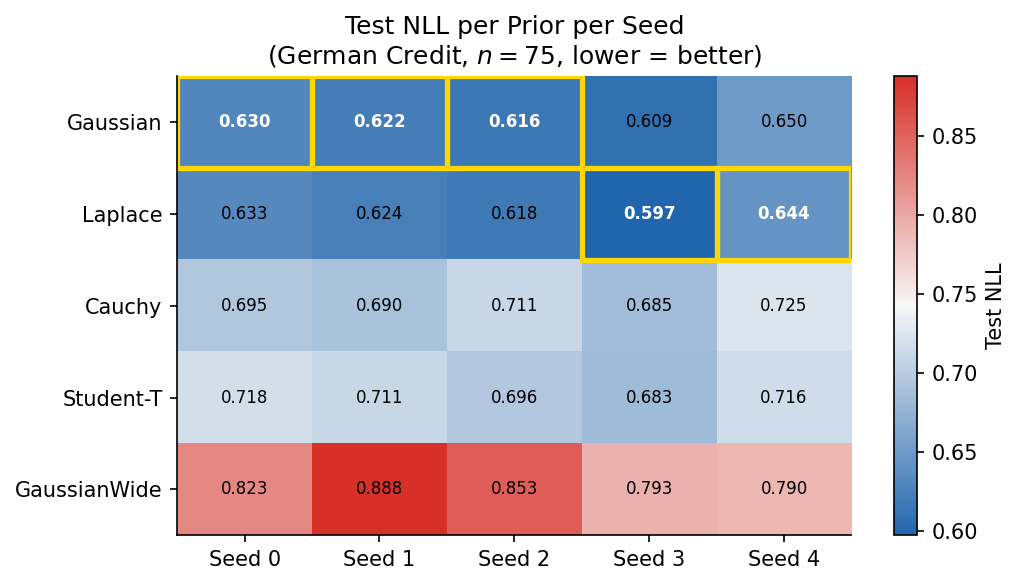

In [2]:
# NLL per prior per seed (low-data, n=75) — from Chapter 4 Table 3
data = {
    'gaussian':      [0.630, 0.622, 0.616, 0.609, 0.650],
    'laplace':       [0.633, 0.624, 0.618, 0.597, 0.644],
    'cauchy':        [0.695, 0.690, 0.711, 0.685, 0.725],
    'student_t':     [0.718, 0.711, 0.696, 0.683, 0.716],
    'gaussian_wide': [0.823, 0.888, 0.853, 0.793, 0.790],
}
priors = list(data.keys())
matrix = np.array([data[p] for p in priors])   # (5, 5)

fig, ax = plt.subplots(figsize=(7, 4))
cmap = LinearSegmentedColormap.from_list('nll', ['#2166ac', '#f7f7f7', '#d73027'])
im = ax.imshow(matrix, cmap=cmap, aspect='auto')

ax.set_xticks(range(5))
ax.set_xticklabels([f'Seed {s}' for s in range(5)])
ax.set_yticks(range(5))
ax.set_yticklabels([PRIOR_LABELS[p] for p in priors])
ax.set_title('Test NLL per Prior per Seed\n(German Credit, $n=75$, lower = better)')

for i in range(5):
    for j in range(5):
        best = np.argmin(matrix[:, j])
        fw   = 'bold' if i == best else 'normal'
        col  = 'white' if i == best else 'black'
        ax.text(j, i, f'{matrix[i,j]:.3f}', ha='center', va='center',
                fontsize=8, fontweight=fw, color=col)

for j in range(5):
    ax.add_patch(plt.Rectangle((j-0.5, np.argmin(matrix[:,j])-0.5),
                                1, 1, fill=False, edgecolor='gold', lw=2.5))

plt.colorbar(im, ax=ax, label='Test NLL')
plt.tight_layout()
plt.savefig(os.path.join(OUTDIR, 'plot_nll_per_seed_lowdata.pdf'), bbox_inches='tight')
plt.show()

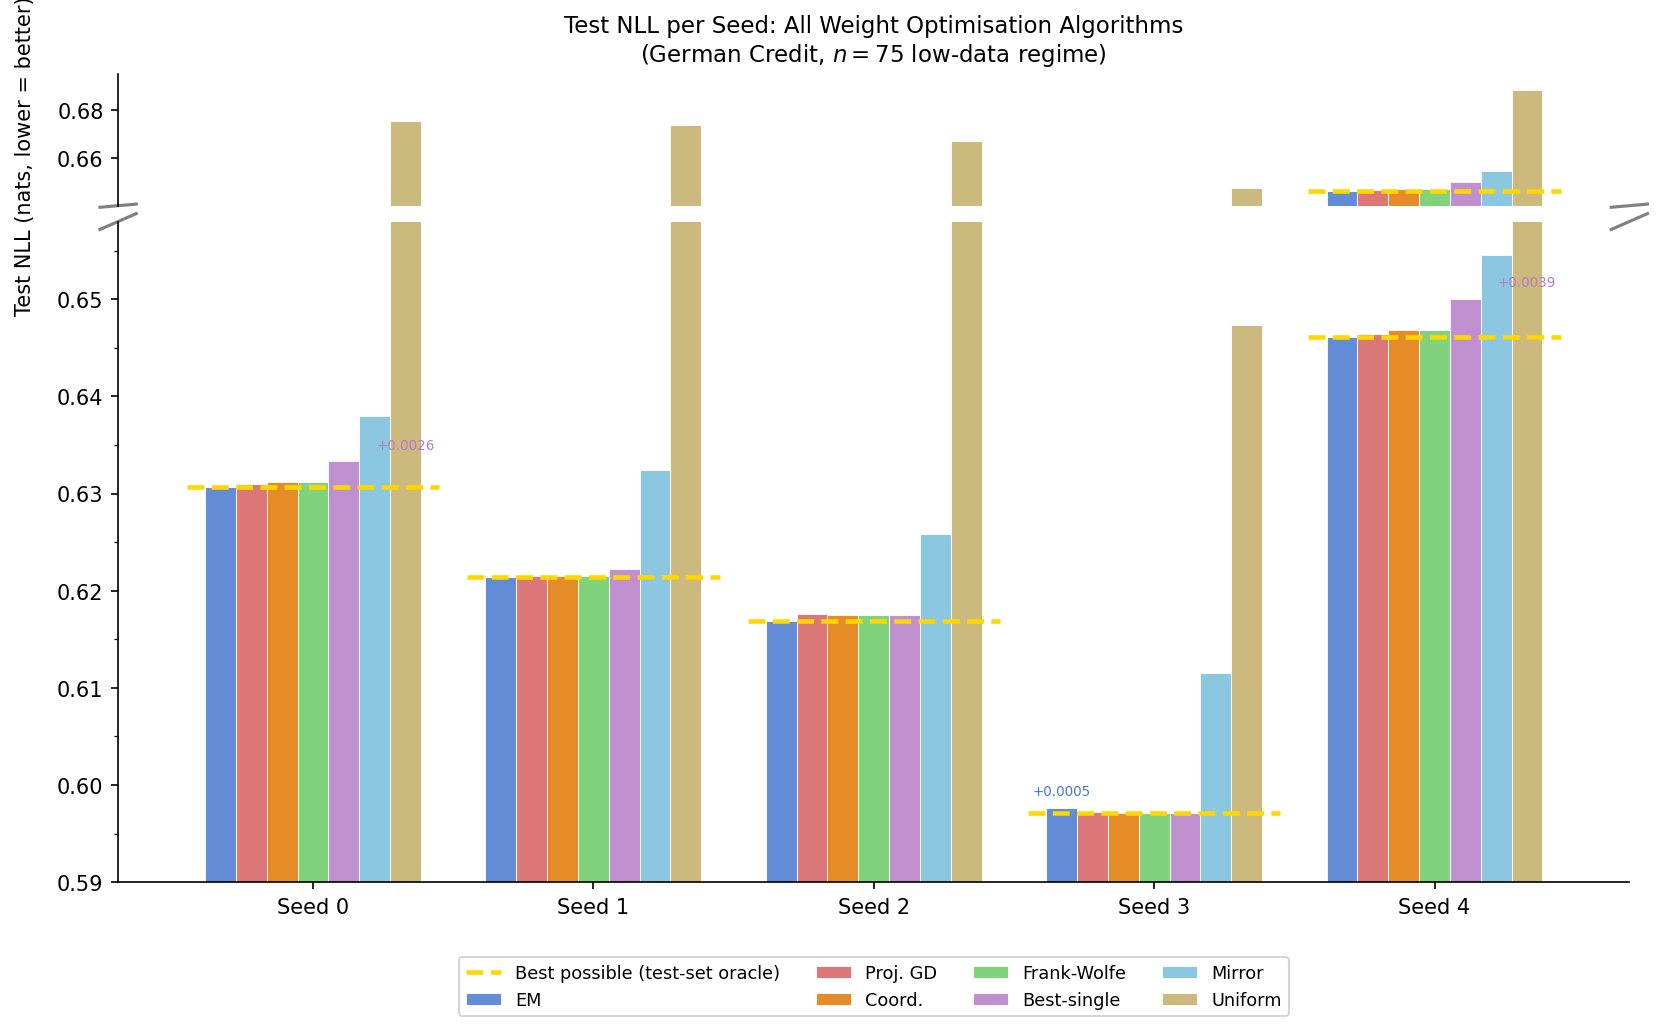

In [10]:
from matplotlib.ticker import MultipleLocator

nll = {
    'em':          [0.6307, 0.6214, 0.6169, 0.5976, 0.6461],
    'proj_gd':     [0.6310, 0.6215, 0.6176, 0.5972, 0.6464],
    'coord':       [0.6312, 0.6215, 0.6175, 0.5971, 0.6468],
    'frank_wolfe': [0.6312, 0.6215, 0.6175, 0.5971, 0.6468],
    'best_single': [0.6333, 0.6222, 0.6175, 0.5971, 0.6500],
    'mirror':      [0.6380, 0.6324, 0.6258, 0.6115, 0.6546],
    'uniform':     [0.6753, 0.6735, 0.6671, 0.6473, 0.6881],
}
oracle = [0.6307, 0.6214, 0.6169, 0.5971, 0.6461]
algos  = list(nll.keys())
x = np.arange(5)
w = 0.11

# height_ratios: top panel (uniform only) is small, bottom panel is tall
fig, (ax_top, ax_bot) = plt.subplots(
    2, 1, figsize=(13, 7), sharex=True,
    gridspec_kw={'height_ratios': [1, 5], 'hspace': 0.04}
)

for ax in (ax_top, ax_bot):
    for i, algo in enumerate(algos):
        offset = (i - len(algos)/2 + 0.5) * w
        ax.bar(x + offset, nll[algo], w,
               label=ALGO_LABELS.get(algo, algo),
               color=COLORS.get(algo, '#888'),
               alpha=0.85, edgecolor='white', lw=0.5)
    for j in range(5):
        ax.hlines(oracle[j], j-0.45, j+0.45,
                  colors='gold', lw=2.2, ls='--', zorder=5)

# Top panel: just the uniform bars
ax_top.set_ylim(0.640, 0.695)
ax_top.yaxis.set_major_locator(MultipleLocator(0.02))
ax_top.spines['bottom'].set_visible(False)
ax_top.tick_params(bottom=False)
ax_top.set_yticks([0.66, 0.68])

# Bottom panel: zoomed into the interesting range
ax_bot.set_ylim(0.590, 0.658)
ax_bot.yaxis.set_major_locator(MultipleLocator(0.010))
ax_bot.yaxis.set_minor_locator(MultipleLocator(0.005))
ax_bot.spines['top'].set_visible(False)

# Break markers on both panels
d = 0.012
for ax, top in [(ax_top, False), (ax_bot, True)]:
    kw = dict(transform=ax.transAxes, color='gray', lw=1.5, clip_on=False)
    y = (1-d, 1+d) if top else (-d, +d)
    ax.plot((-d, +d), y, **kw)
    ax.plot((1-d, 1+d), y, **kw)

# Annotate value differences vs oracle on bottom panel for seeds where
# best-single > oracle (seeds 0, 1, 4) — makes the gap visible numerically
for j, (oracle_val, bs_val, em_val) in enumerate(
    zip(oracle, nll['best_single'], nll['em'])
):
    gap_bs = bs_val - oracle_val
    gap_em = em_val - oracle_val
    if gap_bs > 0.001:
        ax_bot.annotate(f'+{gap_bs:.4f}',
                        xy=(j + 3*w, bs_val + 0.001),
                        fontsize=6.5, color=COLORS['best_single'],
                        ha='center', va='bottom')
    if gap_em > 0.0001:
        ax_bot.annotate(f'+{gap_em:.4f}',
                        xy=(j - 3*w, em_val + 0.001),
                        fontsize=6.5, color=COLORS['em'],
                        ha='center', va='bottom')

ax_bot.set_xticks(x)
ax_bot.set_xticklabels([f'Seed {s}' for s in range(5)], fontsize=10)
ax_bot.set_ylabel('Test NLL (nats, lower = better)', labelpad=8)
ax_bot.yaxis.set_label_coords(-0.055, 1.1)

ax_top.set_title('Test NLL per Seed: All Weight Optimisation Algorithms\n'
                 '(German Credit, $n=75$ low-data regime)', fontsize=11)

ax_bot.plot([], [], color='gold', lw=2.2, ls='--',
            label='Best possible (test-set oracle)')
ax_bot.legend(fontsize=8.5, ncol=4, loc='upper center',
              bbox_to_anchor=(0.5, -0.10))

plt.savefig(os.path.join(OUTDIR, 'plot_nll_per_seed_algorithms.pdf'), bbox_inches='tight')
plt.show()

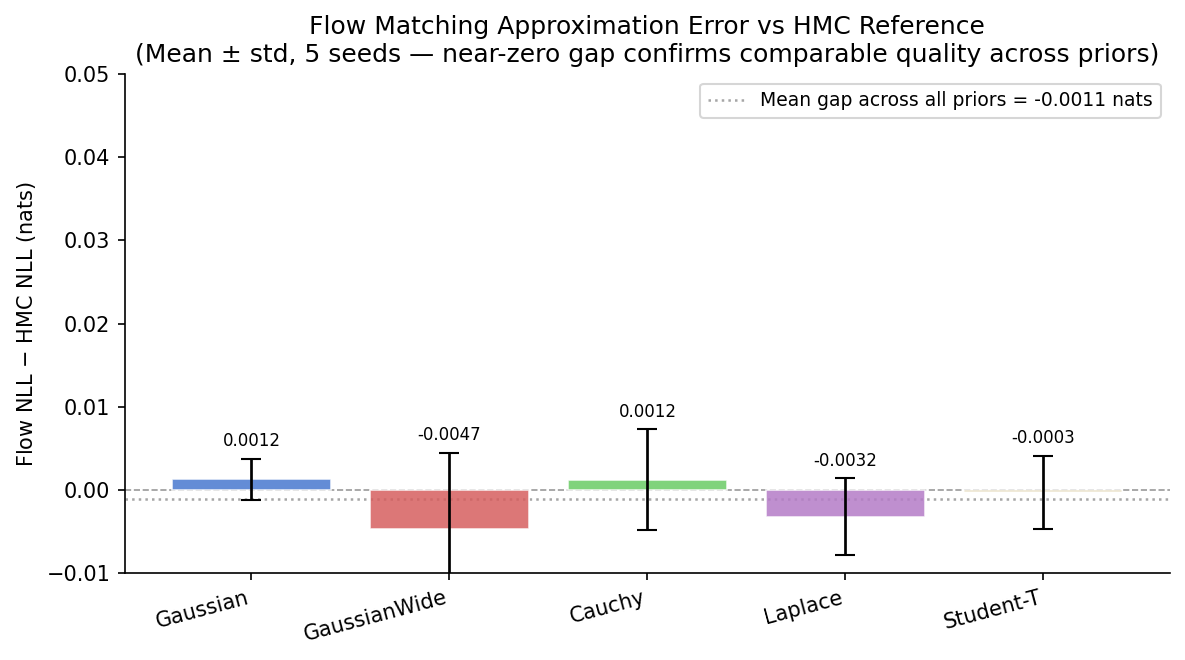

In [17]:
# Plot the GAP (flow NLL - HMC NLL) per prior per seed
# This directly shows the approximation overhead is small and uniform
flow_per_seed = {
    'gaussian':      [0.191864, 0.084364, 0.151222, 0.197084, 0.086490],
    'gaussian_wide': [0.214620, 0.112828, 0.181999, 0.206133, 0.100764],
    'cauchy':        [0.192651, 0.090461, 0.195628, 0.174499, 0.059198],
    'laplace':       [0.205791, 0.101486, 0.151619, 0.191954, 0.099155],
    'student_t':     [0.219411, 0.104917, 0.118414, 0.191113, 0.064141],
}
mcmc_per_seed = {
    'gaussian':      [0.188765, 0.087849, 0.149339, 0.193655, 0.085221],
    'gaussian_wide': [0.214651, 0.114306, 0.204045, 0.210508, 0.096205],
    'cauchy':        [0.199010, 0.093425, 0.184213, 0.174160, 0.055461],
    'laplace':       [0.200311, 0.107581, 0.157814, 0.198791, 0.101605],
    'student_t':     [0.215076, 0.111655, 0.122575, 0.189385, 0.060667],
}

priors = ['gaussian', 'gaussian_wide', 'cauchy', 'laplace', 'student_t']

# Compute gap per prior per seed
gaps = {p: [f - m for f, m in zip(flow_per_seed[p], mcmc_per_seed[p])]
        for p in priors}

gap_mean = {p: np.mean(gaps[p]) for p in priors}
gap_std  = {p: np.std(gaps[p])  for p in priors}

x = np.arange(len(priors))
colors = [COLORS[p] for p in priors]

fig, ax = plt.subplots(figsize=(8, 4.5))

bars = ax.bar(x, [gap_mean[p] for p in priors],
              color=colors, alpha=0.85, edgecolor='white', lw=0.8,
              yerr=[gap_std[p] for p in priors],
              capsize=5, error_kw={'elinewidth': 1.3},
              zorder=3)

# Fix: update reference line and title to match actual data
mean_gap = np.mean([gap_mean[p] for p in priors])

# Replace the axhline for the reference
ax.axhline(mean_gap, color='gray', lw=1.2, ls=':', alpha=0.7,
           label=f'Mean gap across all priors = {mean_gap:.4f} nats', zorder=2)
ax.axhline(0,    color='black', lw=0.8, ls='--', alpha=0.4, zorder=2)

# Annotate each bar with its mean value
for i, p in enumerate(priors):
    ax.text(x[i], gap_mean[p] + gap_std[p] + 0.001,
            f'{gap_mean[p]:.4f}',
            ha='center', va='bottom', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels([PRIOR_LABELS[p] for p in priors], rotation=15, ha='right')
ax.set_ylabel('Flow NLL $-$ HMC NLL (nats)')
ax.set_title('Flow Matching Approximation Error vs HMC Reference\n'
             '(Mean ± std, 5 seeds — gaps within ±0.005 nats across all priors)')
ax.legend(fontsize=9)
ax.set_ylim(-0.01, 0.05)

plt.tight_layout()
plt.savefig(os.path.join(OUTDIR, 'plot_mcmc_vs_flow_gap.pdf'), bbox_inches='tight')
plt.show()

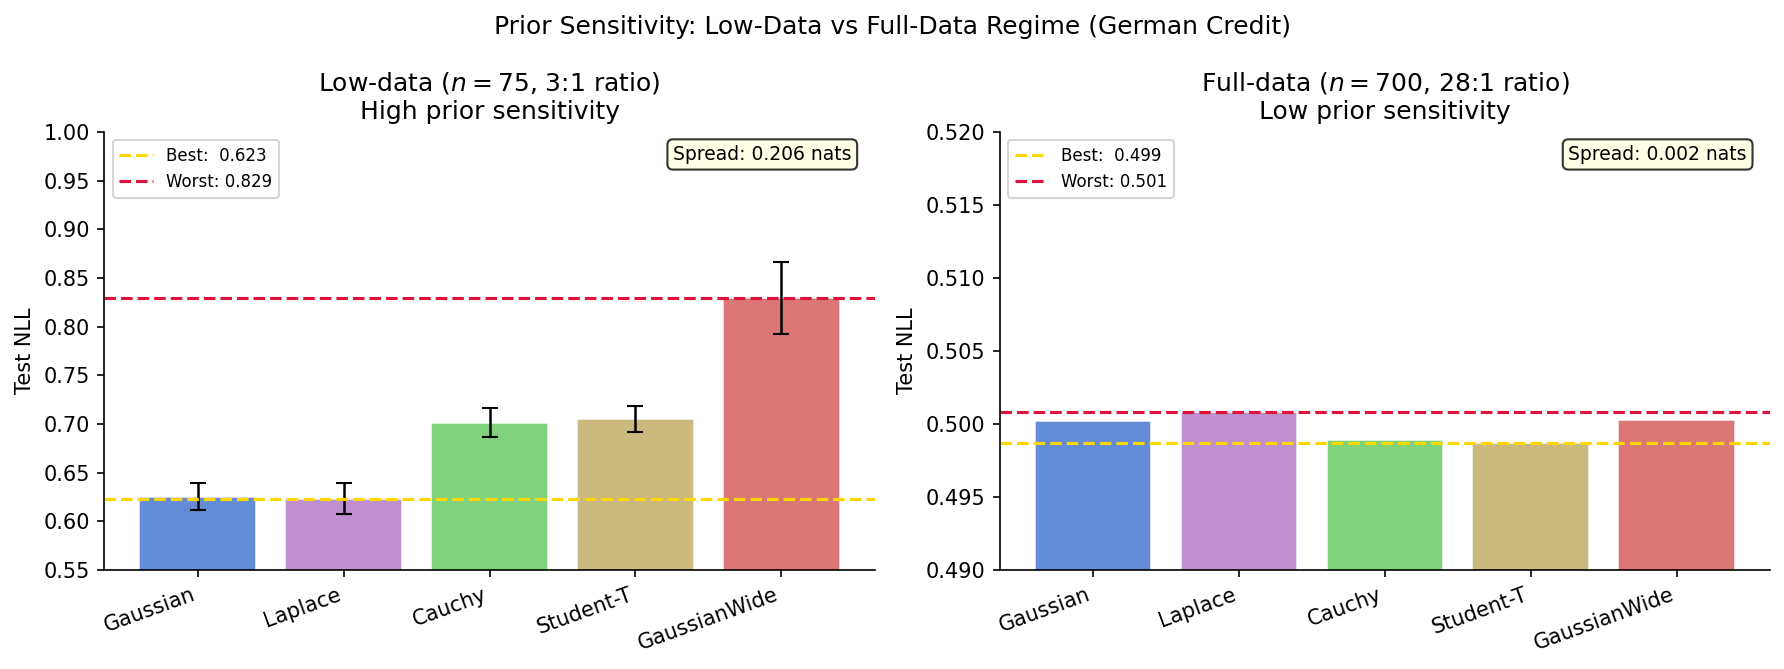

In [12]:
low_data = {p: np.mean(v) for p, v in {
    'gaussian':      [0.630, 0.622, 0.616, 0.609, 0.650],
    'gaussian_wide': [0.823, 0.888, 0.853, 0.793, 0.790],
    'cauchy':        [0.695, 0.690, 0.711, 0.685, 0.725],
    'laplace':       [0.633, 0.624, 0.618, 0.597, 0.644],
    'student_t':     [0.718, 0.711, 0.696, 0.683, 0.716],
}.items()}
low_std = {p: np.std(v) for p, v in {
    'gaussian':      [0.630, 0.622, 0.616, 0.609, 0.650],
    'gaussian_wide': [0.823, 0.888, 0.853, 0.793, 0.790],
    'cauchy':        [0.695, 0.690, 0.711, 0.685, 0.725],
    'laplace':       [0.633, 0.624, 0.618, 0.597, 0.644],
    'student_t':     [0.718, 0.711, 0.696, 0.683, 0.716],
}.items()}
full_data = {'gaussian': 0.5002, 'gaussian_wide': 0.50025,
             'cauchy': 0.49894, 'laplace': 0.50085, 'student_t': 0.49871}

priors = ['gaussian', 'laplace', 'cauchy', 'student_t', 'gaussian_wide']
x = np.arange(len(priors))
colors = [COLORS[p] for p in priors]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, (vals_d, std_d, title, ylim) in zip(axes, [
    (low_data,  low_std,  'Low-data ($n=75$, 3:1 ratio)\nHigh prior sensitivity',   (0.55, 1.0)),
    (full_data, None,     'Full-data ($n=700$, 28:1 ratio)\nLow prior sensitivity', (0.49, 0.52)),
]):
    vals = [vals_d[p] for p in priors]
    errs = [std_d[p] for p in priors] if std_d else None
    ax.bar(x, vals, color=colors, alpha=0.85, edgecolor='white', lw=0.8,
           yerr=errs, capsize=4, error_kw={'elinewidth': 1.2})
    ax.axhline(min(vals), color='gold',    lw=1.5, ls='--', label=f'Best:  {min(vals):.3f}')
    ax.axhline(max(vals), color='crimson', lw=1.5, ls='--', label=f'Worst: {max(vals):.3f}')
    ax.text(0.97, 0.97, f'Spread: {max(vals)-min(vals):.3f} nats',
            transform=ax.transAxes, ha='right', va='top', fontsize=9,
            bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))
    ax.set_xticks(x)
    ax.set_xticklabels([PRIOR_LABELS[p] for p in priors], rotation=20, ha='right')
    ax.set_ylabel('Test NLL')
    ax.set_title(title)
    ax.set_ylim(*ylim)
    ax.legend(fontsize=8)

fig.suptitle('Prior Sensitivity: Low-Data vs Full-Data Regime (German Credit)', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(OUTDIR, 'plot_prior_sensitivity_regimes.pdf'), bbox_inches='tight')
plt.show()

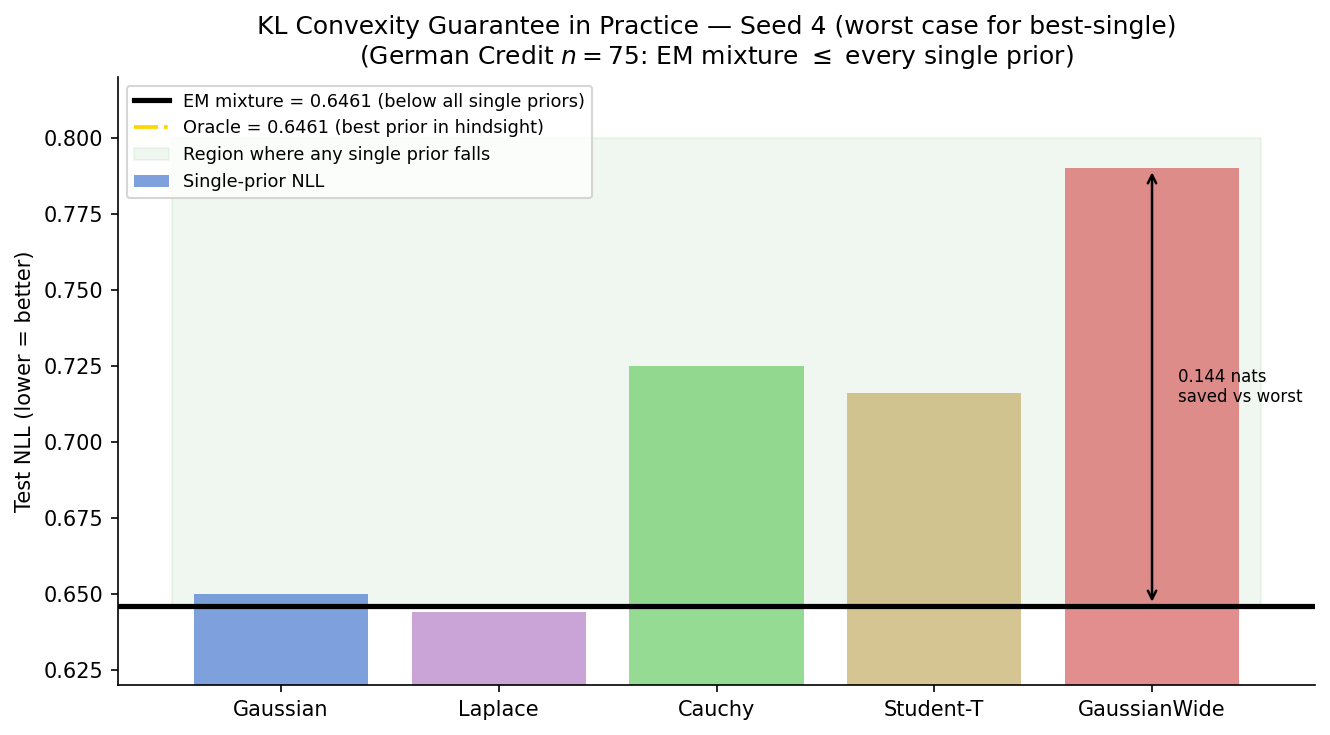

In [18]:
# Use seed 4 — most dramatic contrast between priors
prior_nll_seed4 = {
    'Gaussian':     0.650,
    'Laplace':      0.644,
    'Cauchy':       0.725,
    'Student-T':    0.716,
    'GaussianWide': 0.790,
}
em_nll_seed4     = 0.6461   # EM mixture
oracle_nll_seed4 = 0.6461   # best prior on test set (Laplace)

priors     = list(prior_nll_seed4.keys())
nlls       = list(prior_nll_seed4.values())
x          = np.arange(len(priors))
bar_colors = ['#4878CF','#B47CC7','#6ACC65','#C4AD66','#D65F5F']

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x, nlls, color=bar_colors, alpha=0.7,
       label='Single-prior NLL', zorder=2)

ax.axhline(em_nll_seed4, color='#000000', lw=2.5, ls='-',
           label=f'EM mixture = {em_nll_seed4:.4f} (below all single priors)', zorder=4)
ax.axhline(oracle_nll_seed4, color='gold', lw=1.8, ls='-.',
           label=f'Oracle = {oracle_nll_seed4:.4f} (best prior in hindsight)', zorder=3)

# Shade the region the guarantee covers
ax.fill_between([-0.5, len(priors)-0.5],
                oracle_nll_seed4, max(nlls) + 0.01,
                alpha=0.06, color='green',
                label='Region where any single prior falls')

# Annotate gap between EM and worst single prior
ax.annotate('', xy=(4, max(nlls)), xytext=(4, em_nll_seed4),
            arrowprops=dict(arrowstyle='<->', color='black', lw=1.2))
ax.text(4.12, (max(nlls) + em_nll_seed4)/2,
        f'{max(nlls)-em_nll_seed4:.3f} nats\nsaved vs worst',
        va='center', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(priors)
ax.set_ylabel('Test NLL (lower = better)')
ax.set_title('KL Convexity Guarantee in Practice — Seed 4 (worst case for best-single)\n'
             '(German Credit $n=75$: EM mixture $\\leq$ every single prior)')
ax.set_ylim(0.62, 0.82)
ax.legend(fontsize=8.5, loc='upper left')
plt.tight_layout()
plt.savefig(os.path.join(OUTDIR, 'plot_kl_convexity_illustration.pdf'), bbox_inches='tight')
plt.show()

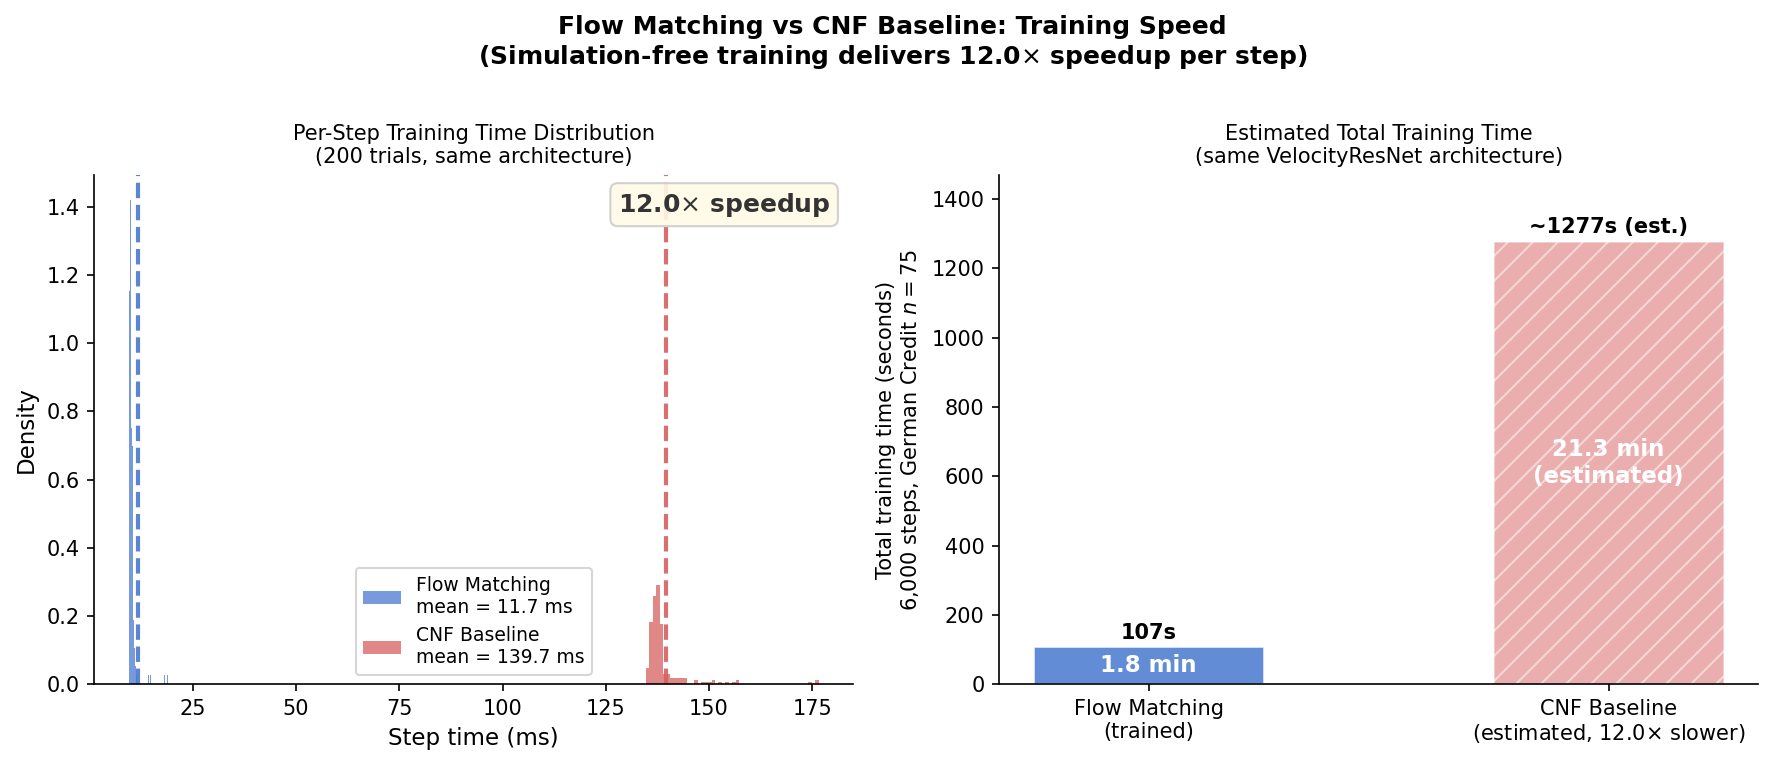


Summary:
  FM  step: 11.7 ms  |  total: 107s (1.8 min)
  CNF step: 139.7 ms  |  est. total: 1277s (21.3 min)
  Speedup:  12.0x


In [19]:
# Load the speed comparison results
import json, os

speed_dir = '../out_speed_comparison'
with open(os.path.join(speed_dir, 'speed_comparison_summary.json')) as f:
    summary = json.load(f)

fm_times  = np.load(os.path.join(speed_dir, 'fm_step_times.npy'))  * 1000  # ms
cnf_times = np.load(os.path.join(speed_dir, 'cnf_step_times.npy')) * 1000  # ms
fm_losses = np.load(os.path.join(speed_dir, 'fm_losses.npy'))

fm_mean   = summary['fm_mean_step_ms']
cnf_mean  = summary['cnf_mean_step_ms']
speedup   = summary['speedup_x']
fm_total  = summary['fm_total_time_s']
cnf_est   = summary.get('estimated_cnf_total_s', cnf_mean / fm_mean * fm_total)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ── Panel 1: Step time distributions ─────────────────────────────────────
ax = axes[0]

# Use percentile clip to remove extreme outliers for cleaner histogram
fm_clip  = fm_times[fm_times  < np.percentile(fm_times,  99)]
cnf_clip = cnf_times[cnf_times < np.percentile(cnf_times, 99)]

ax.hist(fm_clip,  bins=50, alpha=0.75, color='#4878CF',
        label=f'Flow Matching\nmean = {fm_mean:.1f} ms',  density=True)
ax.hist(cnf_clip, bins=50, alpha=0.75, color='#D65F5F',
        label=f'CNF Baseline\nmean = {cnf_mean:.1f} ms', density=True)

ax.axvline(fm_mean,  color='#4878CF', lw=2.0, ls='--', alpha=0.9)
ax.axvline(cnf_mean, color='#D65F5F', lw=2.0, ls='--', alpha=0.9)

ax.set_xlabel('Step time (ms)', fontsize=11)
ax.set_ylabel('Density', fontsize=11)
ax.set_title('Per-Step Training Time Distribution\n(200 trials, same architecture)',
             fontsize=10)
ax.legend(fontsize=9)
ax.text(0.97, 0.97, f'{speedup:.1f}$\\times$ speedup',
        transform=ax.transAxes, ha='right', va='top', fontsize=12,
        fontweight='bold', color='#333',
        bbox=dict(boxstyle='round', facecolor='#fffbe6', edgecolor='#ccc', alpha=0.9))

# ── Panel 2: Total training time comparison ───────────────────────────────
ax = axes[1]

methods = ['Flow Matching\n(trained)', f'CNF Baseline\n(estimated, {speedup:.1f}$\\times$ slower)']
times   = [fm_total, cnf_est]
colors  = ['#4878CF', '#D65F5F']
alphas  = [0.85, 0.5]   # CNF is lighter since it's estimated

bars = ax.bar(methods, times, color=colors, alpha=0.85,
              edgecolor='white', lw=0.8, width=0.5)
bars[1].set_alpha(0.5)   # visually indicate estimation

# Annotate bar tops
for bar, val, label in zip(bars, times, [f'{fm_total:.0f}s', f'~{cnf_est:.0f}s (est.)']):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + cnf_est * 0.01,
            label, ha='center', va='bottom', fontsize=10, fontweight='bold')

# Minutes annotation
ax.text(0, fm_total / 2, f'{fm_total/60:.1f} min',
        ha='center', va='center', fontsize=11, color='white', fontweight='bold')
ax.text(1, cnf_est / 2, f'{cnf_est/60:.1f} min\n(estimated)',
        ha='center', va='center', fontsize=11, color='white', fontweight='bold')

ax.set_ylabel('Total training time (seconds)\n6,000 steps, German Credit $n=75$', fontsize=10)
ax.set_title('Estimated Total Training Time\n(same VelocityResNet architecture)', fontsize=10)
ax.set_ylim(0, cnf_est * 1.15)

# Hatching on CNF bar to indicate estimation
bars[1].set_hatch('//')

fig.suptitle('Flow Matching vs CNF Baseline: Training Speed\n'
             '(Simulation-free training delivers '
             f'{speedup:.1f}$\\times$ speedup per step)',
             fontsize=12, fontweight='bold', y=1.01)

plt.tight_layout()
plt.savefig(os.path.join(OUTDIR, 'plot_speed_comparison.pdf'), bbox_inches='tight')
plt.show()

print(f'\nSummary:')
print(f'  FM  step: {fm_mean:.1f} ms  |  total: {fm_total:.0f}s ({fm_total/60:.1f} min)')
print(f'  CNF step: {cnf_mean:.1f} ms  |  est. total: {cnf_est:.0f}s ({cnf_est/60:.1f} min)')
print(f'  Speedup:  {speedup:.1f}x')

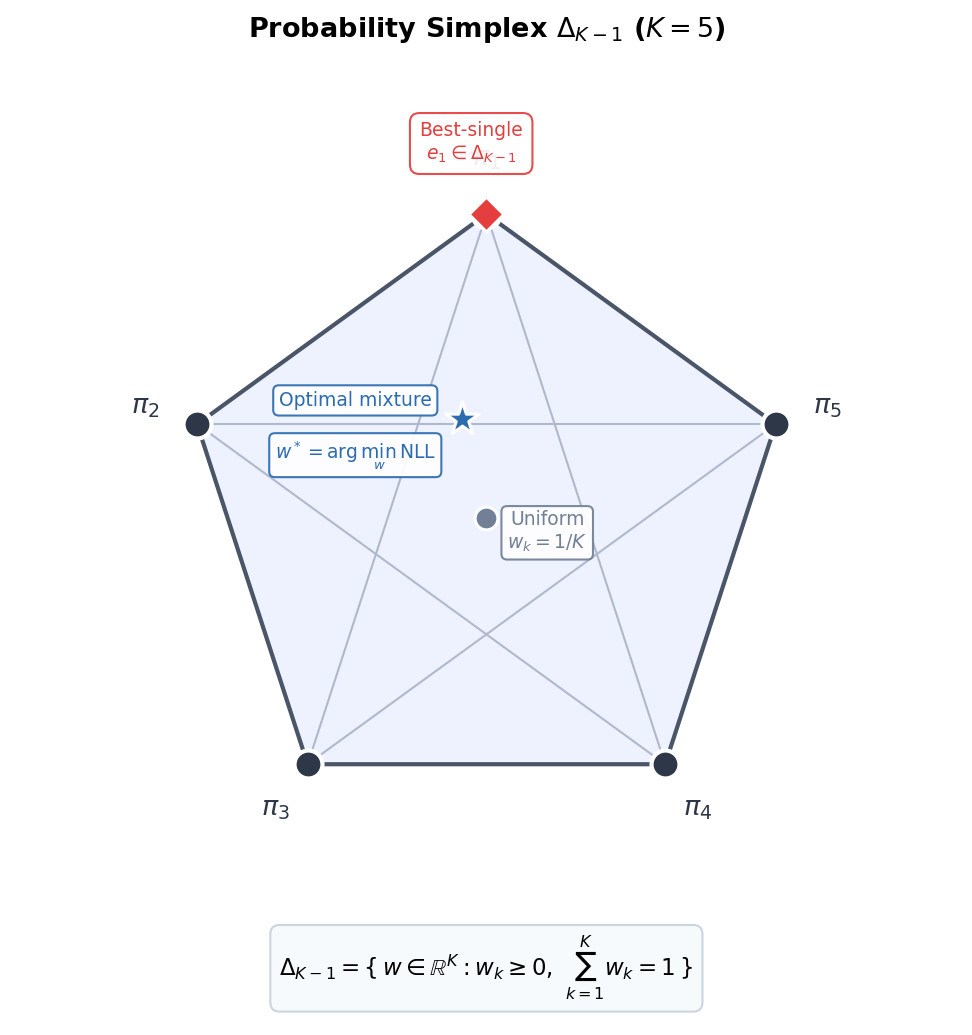

In [33]:
fig, ax = plt.subplots(figsize=(7, 7))

K = 5

# Vertex positions on unit circle
angles = [np.pi/2 + 2*np.pi*i/K for i in range(K)]
verts  = np.array([[np.cos(a), np.sin(a)] for a in angles])

# ── Shaded interior ────────────────────────────────────────────────────────
from matplotlib.patches import Polygon as MplPolygon
interior = MplPolygon(verts, closed=True,
                       facecolor='#eef2ff', edgecolor='none', zorder=0)
ax.add_patch(interior)

# ── All edges ─────────────────────────────────────────────────────────────
for i in range(K):
    for j in range(i+1, K):
        ax.plot([verts[i,0], verts[j,0]],
                [verts[i,1], verts[j,1]],
                color='#b0b8cc', lw=1.0, zorder=1)

# ── Outer polygon border ───────────────────────────────────────────────────
border = MplPolygon(verts, closed=True,
                     facecolor='none', edgecolor='#4a5568', lw=2.0, zorder=2)
ax.add_patch(border)

# ── Vertex dots labelled π_1 ... π_K ──────────────────────────────────────
for i, (v, a) in enumerate(zip(verts, angles)):
    ax.scatter(*v, s=180, color='#2d3748', zorder=5,
               edgecolors='white', lw=2.0)
    label_r = 1.18
    ax.text(np.cos(a)*label_r, np.sin(a)*label_r,
            f'$\\pi_{i+1}$',
            ha='center', va='center', fontsize=13, color='#2d3748')

# ── Three example interior points ─────────────────────────────────────────
def s2d(w):
    return sum(wi*vi for wi, vi in zip(w, verts))

# EM optimal mixture — interior point
w_em      = np.array([0.35, 0.28, 0.08, 0.12, 0.17])
# Best single (π_1 vertex)
w_single  = np.array([1.0,  0.0,  0.0,  0.0,  0.0 ])
# Uniform
w_uniform = np.ones(K) / K

xy_em     = s2d(w_em)
xy_single = s2d(w_single)
xy_unif   = s2d(w_uniform)

ax.scatter(*xy_single, s=140, color='#e53e3e', marker='D', zorder=6,
           edgecolors='white', lw=1.5)
ax.scatter(*xy_unif,   s=120, color='#718096', marker='o', zorder=6,
           edgecolors='white', lw=1.5)
ax.scatter(*xy_em,     s=280, color='#2b6cb0', marker='*', zorder=7,
           edgecolors='white', lw=1.5)

# Labels with clean boxes
label_style = dict(fontsize=9, ha='center',
                   bbox=dict(boxstyle='round,pad=0.3',
                             facecolor='white', lw=1.0, alpha=0.92))

# Replace the three text label lines with better positioned offsets

ax.text(xy_single[0] - 0.05, xy_single[1] + 0.18,
        'Best-single\n$e_1 \\in \\Delta_{K-1}$',
        color='#e53e3e', fontsize=9, ha='center',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='white',
                  edgecolor='#e53e3e', lw=1.0, alpha=0.92))

ax.text(xy_unif[0] + 0.2, xy_unif[1]-0.1,
        'Uniform\n$w_k = 1/K$',
        color='#718096', fontsize=9, ha='center',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                  edgecolor='#718096', lw=1.0, alpha=0.92))

xy_em_label = (xy_em[0] - 0.45, xy_em[1] - 0.14)

ax.text(xy_em_label[0]+0.1, xy_em_label[1] + 0.2,
        'Optimal mixture',
        color='#2b6cb0', fontsize=9, ha='center', va='center',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                  edgecolor='#2b6cb0', lw=1.0, alpha=0.92))

ax.text(xy_em_label[0]+0.1, xy_em_label[1] + 0.02,
        '$w^* = \\arg\\min_w\\, \\mathrm{NLL}$',
        color='#2b6cb0', fontsize=9, ha='center', va='center',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                  edgecolor='#2b6cb0', lw=1.0, alpha=0.92))

# ── Simplex constraint annotation at bottom ────────────────────────────────
ax.text(0.0, -1.48,
        '$\\Delta_{K-1} = \\{\\, w \\in \\mathbb{R}^K : w_k \\geq 0,\\ '
        '\\sum_{k=1}^K w_k = 1 \\,\\}$',
        ha='center', va='center', fontsize=11,
        bbox=dict(boxstyle='round,pad=0.4', facecolor='#f7fafc',
                  edgecolor='#cbd5e0', lw=1.0))

ax.set_xlim(-1.55, 1.55)
ax.set_ylim(-1.65, 1.50)
ax.set_aspect('equal')
ax.axis('off')
ax.set_title('Probability Simplex $\\Delta_{K-1}$ ($K=5$)',
             fontsize=13, fontweight='bold', pad=12)

plt.tight_layout()
plt.savefig(os.path.join(OUTDIR, 'theory_simplex_diagram.pdf'), bbox_inches='tight')
plt.show()

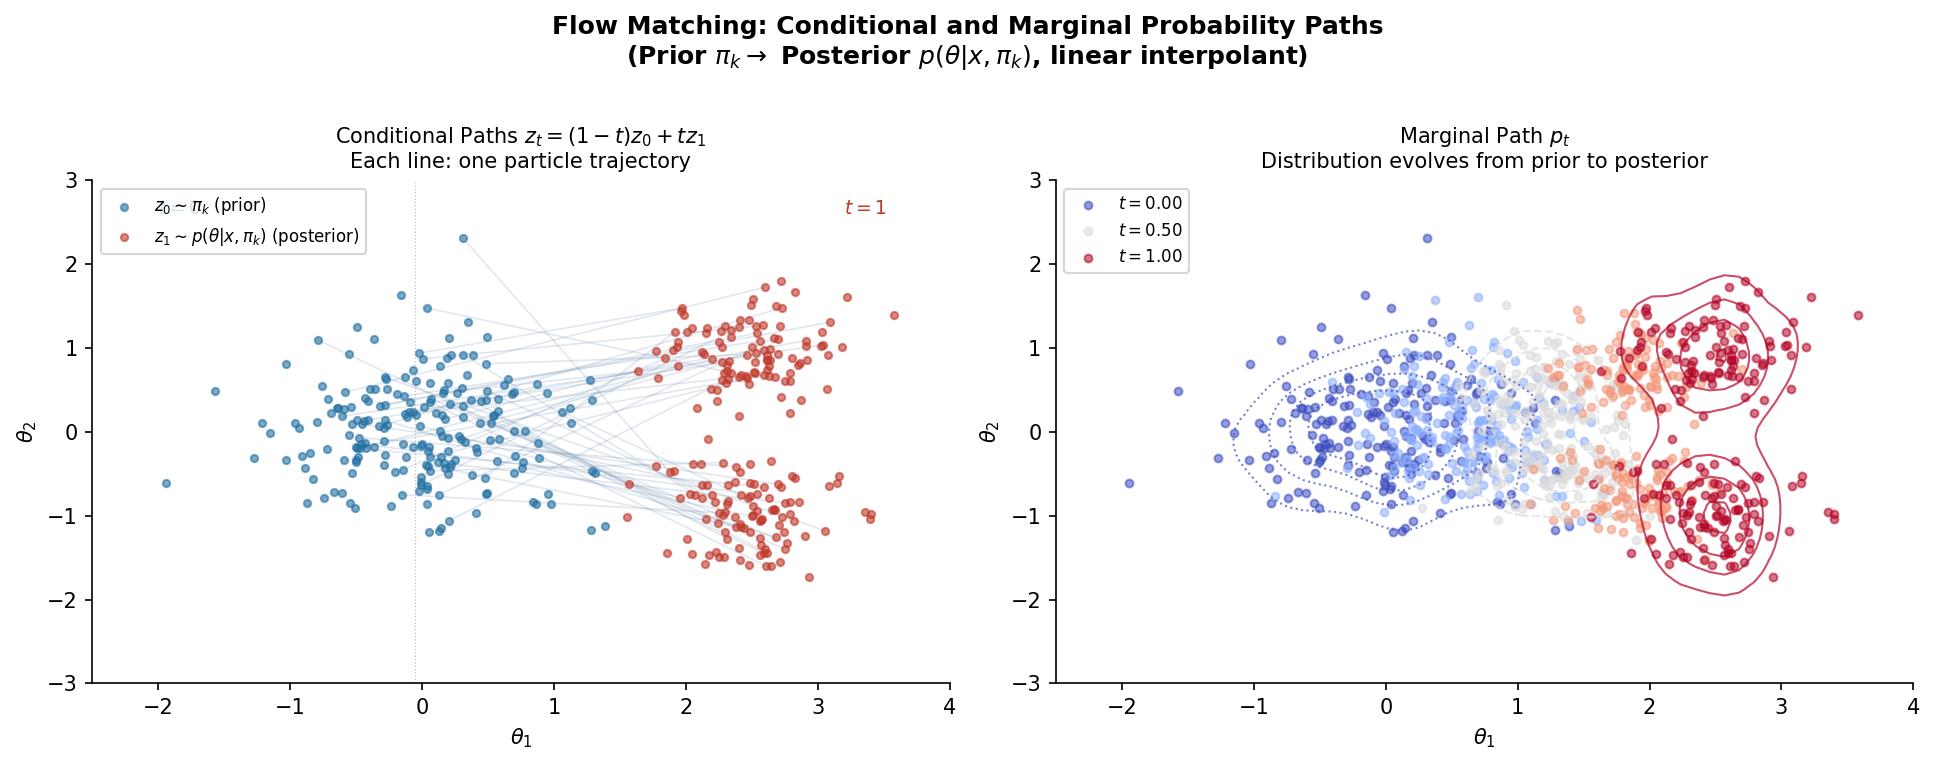

In [34]:
np.random.seed(42)
N = 200
T_steps = 50
t_vals = np.linspace(0, 1, T_steps)

# Source: prior N(0, I) in 2D
z0 = np.random.randn(N, 2) * 0.6

# Target: two-cluster posterior (bimodal)
z1_a = np.random.randn(N//2, 2) * 0.35 + np.array([2.5,  1.0])
z1_b = np.random.randn(N//2, 2) * 0.35 + np.array([2.5, -1.0])
z1   = np.vstack([z1_a, z1_b])

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Left: conditional paths φ_t(z0 | z1) ─────────────────────────────────
ax = axes[0]
# Draw trajectory lines for a subset of particles
for i in range(0, N, 4):
    traj = np.array([(1-t)*z0[i] + t*z1[i] for t in t_vals])
    ax.plot(traj[:,0], traj[:,1],
            color='#5b7fa6', alpha=0.18, lw=0.8, zorder=1)

# Source and target scatter
ax.scatter(z0[:,0], z0[:,1], s=12, color='#2471a3', alpha=0.6,
           zorder=3, label='$z_0 \\sim \\pi_k$ (prior)')
ax.scatter(z1[:,0], z1[:,1], s=12, color='#c0392b', alpha=0.6,
           zorder=3, label='$z_1 \\sim p(\\theta|x,\\pi_k)$ (posterior)')

ax.set_title('Conditional Paths $z_t = (1-t)z_0 + tz_1$\n'
             'Each line: one particle trajectory',
             fontsize=10)
ax.legend(fontsize=8, loc='upper left')
ax.set_xlim(-2.5, 4.0); ax.set_ylim(-3.0, 3.0)
ax.set_xlabel('$\\theta_1$'); ax.set_ylabel('$\\theta_2$')
ax.axvline(x=-0.05, color='gray', lw=0.6, ls=':', alpha=0.5)
ax.text(-2.0,  2.6, '$t=0$', fontsize=9, color='#2471a3')
ax.text( 3.2,  2.6, '$t=1$', fontsize=9, color='#c0392b')

# ── Right: marginal path p_t at several time slices ───────────────────────
ax = axes[1]
slice_times = [0.0, 0.25, 0.5, 0.75, 1.0]
cmap_marg   = plt.cm.coolwarm

for t in slice_times:
    z_t = (1-t)*z0 + t*z1
    color = cmap_marg(t)
    ax.scatter(z_t[:,0], z_t[:,1], s=14,
               color=color, alpha=0.55, zorder=2,
               label=f'$t={t:.2f}$' if t in [0.0, 0.5, 1.0] else None)

# Add kernel density contours at t=0, 0.5, 1.0
from scipy.stats import gaussian_kde
for t, ls in [(0.0, ':'), (0.5, '--'), (1.0, '-')]:
    z_t = (1-t)*z0 + t*z1
    try:
        kde = gaussian_kde(z_t.T, bw_method=0.4)
        xx, yy = np.meshgrid(np.linspace(-2.5, 4.0, 60),
                              np.linspace(-3.0, 3.0, 60))
        zz = kde(np.vstack([xx.ravel(), yy.ravel()])).reshape(xx.shape)
        ax.contour(xx, yy, zz, levels=4,
                   colors=[cmap_marg(t)], linewidths=1.0,
                   linestyles=ls, alpha=0.7)
    except Exception:
        pass

ax.set_title('Marginal Path $p_t$\n'
             'Distribution evolves from prior to posterior',
             fontsize=10)
ax.legend(fontsize=8, loc='upper left')
ax.set_xlim(-2.5, 4.0); ax.set_ylim(-3.0, 3.0)
ax.set_xlabel('$\\theta_1$'); ax.set_ylabel('$\\theta_2$')

fig.suptitle('Flow Matching: Conditional and Marginal Probability Paths\n'
             '(Prior $\\pi_k \\to$ Posterior $p(\\theta|x,\\pi_k)$, '
             'linear interpolant)',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(OUTDIR, 'theory_fm_paths.pdf'), bbox_inches='tight')
plt.show()

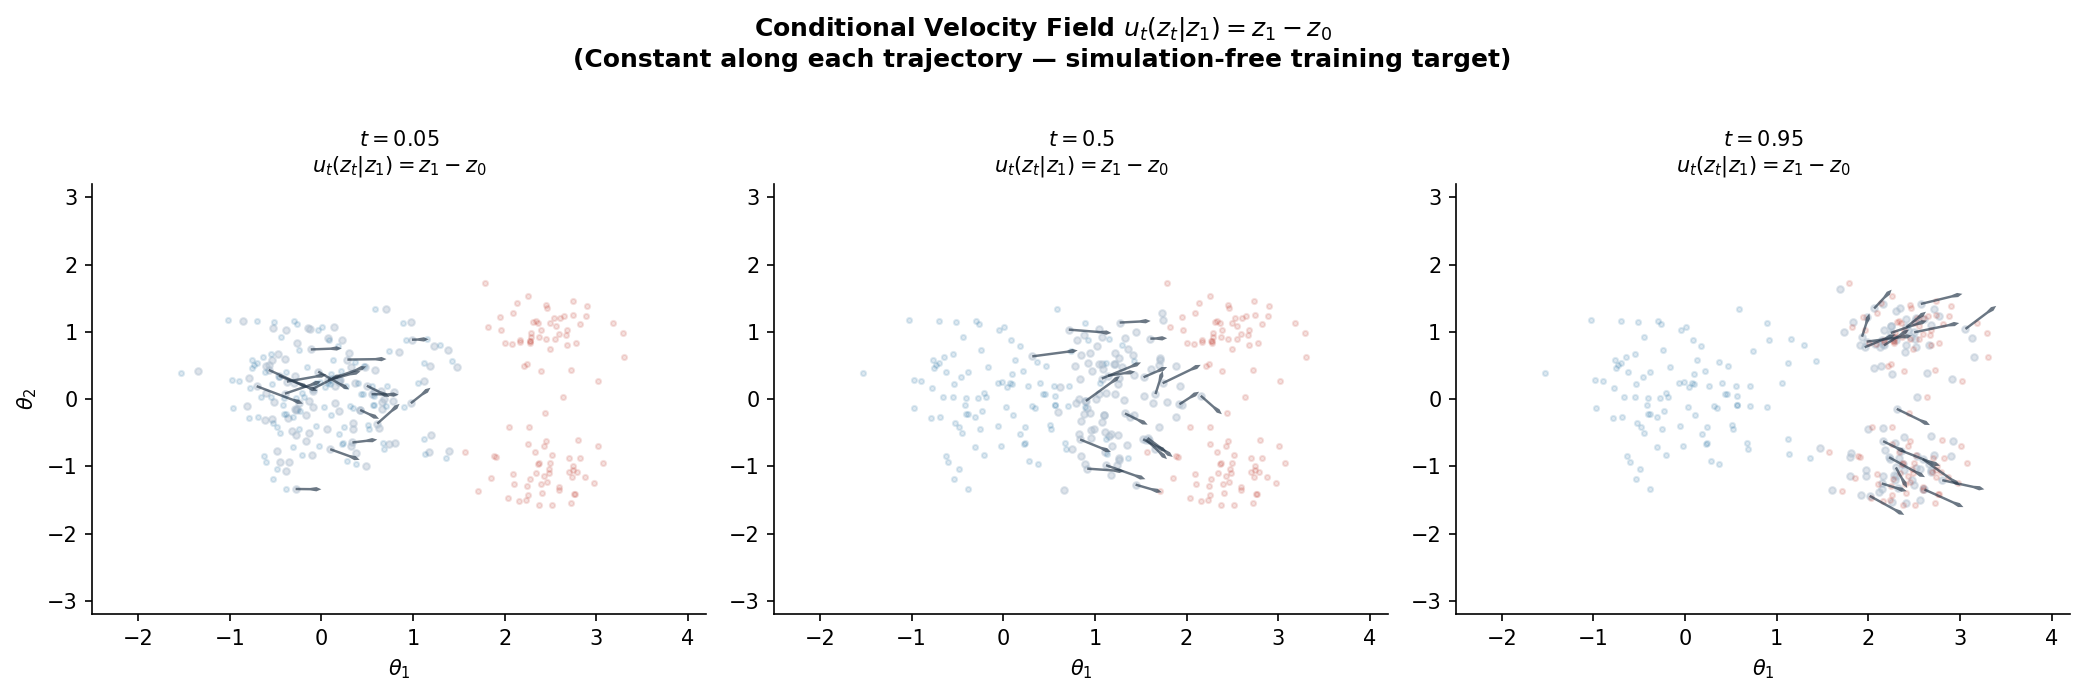

In [41]:
np.random.seed(0)
N = 100

z0 = np.random.randn(N, 2) * 0.6
z1_a = np.random.randn(N//2, 2) * 0.35 + np.array([2.5,  1.0])
z1_b = np.random.randn(N//2, 2) * 0.35 + np.array([2.5, -1.0])
z1   = np.vstack([z1_a, z1_b])

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

for ax, t in zip(axes, [0.05, 0.5, 0.95]):
    # Current positions
    z_t = (1-t)*z0 + t*z1          # (N, 2)
    # True conditional velocity u_t(z|z1) = z1 - z0
    u_t = z1 - z0                   # (N, 2)

    # Subsample for clarity
    idx = np.random.choice(N, 20, replace=False)

    # Draw particle positions
    ax.scatter(z_t[:,0], z_t[:,1], s=10, color='#aabbcc', alpha=0.4, zorder=1)

    # Draw velocity arrows for subsample
    ax.quiver(z_t[idx,0], z_t[idx,1],
              u_t[idx,0], u_t[idx,1],
              color='#2c3e50', alpha=0.7, scale=50,
              headwidth=1.75, headlength=2,
              width=0.004, zorder=3)

    # Highlight source and target clusters faintly
    ax.scatter(z0[:,0], z0[:,1], s=6, color='#2471a3', alpha=0.15, zorder=2)
    ax.scatter(z1[:,0], z1[:,1], s=6, color='#c0392b', alpha=0.15, zorder=2)

    ax.set_title(f'$t = {t}$\n$u_t(z_t | z_1) = z_1 - z_0$', fontsize=10)
    ax.set_xlim(-2.5, 4.2); ax.set_ylim(-3.2, 3.2)
    ax.set_xlabel('$\\theta_1$')
    if ax == axes[0]:
        ax.set_ylabel('$\\theta_2$')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig.suptitle('Conditional Velocity Field $u_t(z_t | z_1) = z_1 - z_0$\n'
             '(Constant along each trajectory — simulation-free training target)',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(OUTDIR, 'theory_fm_velocity.pdf'), bbox_inches='tight')
plt.show()

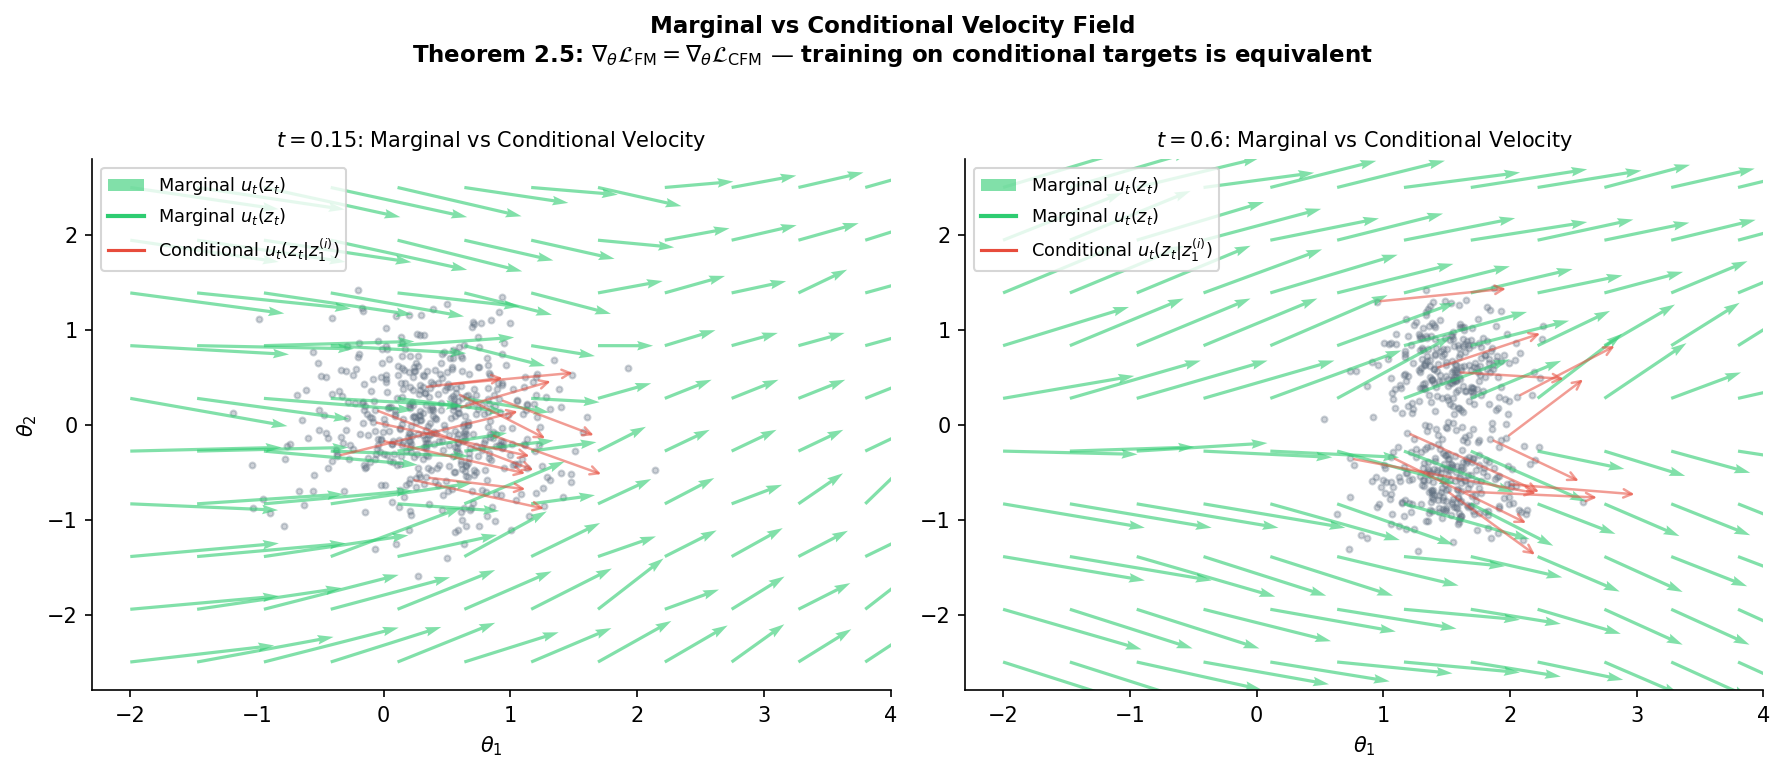

In [42]:
np.random.seed(1)
N = 500

z0 = np.random.randn(N, 2) * 0.6
z1_a = np.random.randn(N//2, 2) * 0.3 + np.array([2.5,  1.0])
z1_b = np.random.randn(N//2, 2) * 0.3 + np.array([2.5, -1.0])
z1   = np.vstack([z1_a, z1_b])

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, t in zip(axes, [0.15, 0.6]):
    z_t = (1-t)*z0 + t*z1

    # Marginal velocity: average conditional over z1 samples near each z_t point
    # Approximate by IS weighting (for illustration, use simple mean)
    u_marginal_mean = (z1 - z0).mean(axis=0)  # rough marginal for illustration

    # Grid for marginal field
    gx = np.linspace(-2.0, 3.8, 12)
    gy = np.linspace(-2.5, 2.5, 10)
    GX, GY = np.meshgrid(gx, gy)

    # Approximate marginal velocity at grid points via nearest-neighbour mean
    from scipy.spatial import cKDTree
    tree = cKDTree(z_t)
    _, idx_nn = tree.query(np.c_[GX.ravel(), GY.ravel()], k=8)
    U_marg = (z1 - z0)[idx_nn].mean(axis=1).reshape(GX.shape[0], GX.shape[1], 2)

    # Draw marginal field in background
    ax.quiver(GX, GY,
              U_marg[:,:,0], U_marg[:,:,1],
              color='#2ecc71', alpha=0.6, scale=20,
              headwidth=3, width=0.004,
              label='Marginal $u_t(z_t)$', zorder=2)

    # Draw a few conditional fields for individual z1 samples
    sample_idx = np.random.choice(N, 12, replace=False)
    for si in sample_idx:
        z1_s  = z1[si]
        z_pts = np.column_stack([
            np.linspace(-2.0, 3.5, 8),
            np.zeros(8)
        ])
        # conditional velocity for this z1: always z1 - z0 direction
        # show at current z_t position for this particle
        ax.annotate('', xy=z_t[si] + 0.35*(z1[si]-z0[si]),
                    xytext=z_t[si],
                    arrowprops=dict(arrowstyle='->', color='#e74c3c',
                                    lw=1.2, alpha=0.55))

    # Particle scatter
    ax.scatter(z_t[:,0], z_t[:,1], s=8, color='#5d6d7e', alpha=0.3, zorder=1)

    ax.plot([],[], color='#2ecc71', lw=2,
            label='Marginal $u_t(z_t)$')
    ax.plot([],[], color='#e74c3c', lw=1.5,
            label='Conditional $u_t(z_t|z_1^{(i)})$')
    ax.legend(fontsize=8.5, loc='upper left')
    ax.set_title(f'$t = {t}$: Marginal vs Conditional Velocity',
                 fontsize=10)
    ax.set_xlim(-2.3, 4.0); ax.set_ylim(-2.8, 2.8)
    ax.set_xlabel('$\\theta_1$')
    if ax == axes[0]:
        ax.set_ylabel('$\\theta_2$')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig.suptitle('Marginal vs Conditional Velocity Field\n'
             'Theorem 2.5: $\\nabla_\\theta \\mathcal{L}_{\\mathrm{FM}}'
             ' = \\nabla_\\theta \\mathcal{L}_{\\mathrm{CFM}}$ '
             '— training on conditional targets is equivalent',
             fontsize=11, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(OUTDIR, 'theory_fm_marginal_vs_conditional.pdf'),
            bbox_inches='tight')
plt.show()